In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df1:pd.DataFrame=pd.read_csv('idealista18_1.csv')
df2:pd.DataFrame=pd.read_csv('idealista18_2.csv')
df:pd.DataFrame=pd.concat([df1,df2],ignore_index=True).drop_duplicates()

In [16]:
original:pd.DataFrame=pd.concat([df1,df2],ignore_index=True).drop_duplicates()

In [23]:
pd.set_option("display.max_columns", None)
df

,ASSETID,PERIOD,PRICE,UNITPRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,HASLIFT,HASAIRCONDITIONING,AMENITYID,HASPARKINGSPACE,ISPARKINGSPACEINCLUDEDINPRICE,PARKINGSPACEPRICE,HASNORTHORIENTATION,HASSOUTHORIENTATION,HASEASTORIENTATION,HASWESTORIENTATION,HASBOXROOM,HASWARDROBE,HASSWIMMINGPOOL,HASDOORMAN,HASGARDEN,ISDUPLEX,ISSTUDIO,ISINTOPFLOOR,CONSTRUCTIONYEAR,FLOORCLEAN,FLATLOCATIONID,CADCONSTRUCTIONYEAR,CADMAXBUILDINGFLOOR,CADDWELLINGCOUNT,CADASTRALQUALITYID,BUILTTYPEID_1,BUILTTYPEID_2,BUILTTYPEID_3,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_STREET,LONGITUDE,LATITUDE,CITYNAME,BUILTTYPEID
0,A12377633511549727658,201812,109000,1730.158730,63,3,1,1,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1965.0,3.0,1.0,1965,5,22,7.0,0,0,1,4.166611,0.313529,2.814425,-3.726785,40.383510,Madrid,3
1,A7691539882862170545,201809,155000,2384.615385,65,2,1,0,1,1,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,4.0,1.0,1967,6,79,6.0,0,0,1,4.477237,0.109565,2.934052,-3.726764,40.380375,Madrid,3
2,A4316988685482817826,201809,158000,2025.641026,78,3,1,1,1,1,3,0,0,1,0,1,1,1,0,1,0,0,0,0,0,0,NaN,2.0,1.0,1955,4,15,6.0,0,0,1,4.294954,0.217547,2.788894,-3.725683,40.381796,Madrid,3
3,A12032801997263349694,201812,126000,1680.000000,75,3,1,1,1,1,3,0,0,1,1,1,0,0,0,1,0,0,1,0,0,0,1971.0,2.0,1.0,1971,5,11,6.0,0,0,1,4.861939,0.355738,3.455590,-3.732578,40.378816,Madrid,3
4,A16032891972289007994,201803,184000,1840.000000,100,3,2,1,1,1,3,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,NaN,1.0,1.0,1968,5,15,6.0,0,0,1,4.786463,0.395206,3.399424,-3.732196,40.379431,Madrid,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189918,A5469264850873866443,201809,72000,1142.857143,63,2,1,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,NaN,3.0,1.0,1968,5,11,6.0,0,1,0,4.829951,0.385920,3.421160,-3.732238,40.378998,Madrid,2
189919,A711055539203140082,201809,136000,1360.000000,100,3,2,1,0,1,3,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,NaN,3.0,1.0,1987,7,29,5.0,0,0,1,5.363864,0.155790,3.866306,-3.735504,40.374896,Madrid,3
189920,A4740286493963203916,201812,119000,1676.056338,71,3,1,0,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,1955,4,17,5.0,0,0,1,3.999653,0.354627,2.489760,-3.722853,40.383724,Madrid,3
189921,A15722582369407807529,201809,96000,1500.000000,64,3,1,1,1,0,3,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1970.0,3.0,2.0,1970,7,21,6.0,0,1,0,4.574522,0.151881,3.005669,-3.727214,40.379570,Madrid,2


In [18]:
unicos:pd.Series=df.nunique(dropna=False)
tipos:pd.Series=df.dtypes
nnans:pd.Series=df.isna().sum().sort_values(ascending=False)
constantes=unicos[unicos==1].keys()
binarios=unicos[unicos==2].keys()
nans=nnans[nnans>0].keys()

In [19]:
nans

Index(['CONSTRUCTIONYEAR', 'FLATLOCATIONID', 'FLOORCLEAN',
       'CADASTRALQUALITYID'],
      dtype='str')

In [20]:
df=df.drop(columns=constantes)

In [21]:
df=df.assign(
    BUILTTYPEID=np.select(
        [df['BUILTTYPEID_1']==1,df['BUILTTYPEID_2']==1,df['BUILTTYPEID_3']==1],
        [1,2,3]
    )
)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189923 entries, 0 to 189922
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ASSETID                        189923 non-null  str    
 1   PERIOD                         189923 non-null  int64  
 2   PRICE                          189923 non-null  int64  
 3   UNITPRICE                      189923 non-null  float64
 4   CONSTRUCTEDAREA                189923 non-null  int64  
 5   ROOMNUMBER                     189923 non-null  int64  
 6   BATHNUMBER                     189923 non-null  int64  
 7   HASTERRACE                     189923 non-null  int64  
 8   HASLIFT                        189923 non-null  int64  
 9   HASAIRCONDITIONING             189923 non-null  int64  
 10  AMENITYID                      189923 non-null  int64  
 11  HASPARKINGSPACE                189923 non-null  int64  
 12  ISPARKINGSPACEINCLUDEDINPRICE  189923 non

In [24]:
df

,ASSETID,PERIOD,PRICE,UNITPRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,HASLIFT,HASAIRCONDITIONING,AMENITYID,HASPARKINGSPACE,ISPARKINGSPACEINCLUDEDINPRICE,PARKINGSPACEPRICE,HASNORTHORIENTATION,HASSOUTHORIENTATION,HASEASTORIENTATION,HASWESTORIENTATION,HASBOXROOM,HASWARDROBE,HASSWIMMINGPOOL,HASDOORMAN,HASGARDEN,ISDUPLEX,ISSTUDIO,ISINTOPFLOOR,CONSTRUCTIONYEAR,FLOORCLEAN,FLATLOCATIONID,CADCONSTRUCTIONYEAR,CADMAXBUILDINGFLOOR,CADDWELLINGCOUNT,CADASTRALQUALITYID,BUILTTYPEID_1,BUILTTYPEID_2,BUILTTYPEID_3,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_STREET,LONGITUDE,LATITUDE,CITYNAME,BUILTTYPEID
0,A12377633511549727658,201812,109000,1730.158730,63,3,1,1,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1965.0,3.0,1.0,1965,5,22,7.0,0,0,1,4.166611,0.313529,2.814425,-3.726785,40.383510,Madrid,3
1,A7691539882862170545,201809,155000,2384.615385,65,2,1,0,1,1,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,4.0,1.0,1967,6,79,6.0,0,0,1,4.477237,0.109565,2.934052,-3.726764,40.380375,Madrid,3
2,A4316988685482817826,201809,158000,2025.641026,78,3,1,1,1,1,3,0,0,1,0,1,1,1,0,1,0,0,0,0,0,0,NaN,2.0,1.0,1955,4,15,6.0,0,0,1,4.294954,0.217547,2.788894,-3.725683,40.381796,Madrid,3
3,A12032801997263349694,201812,126000,1680.000000,75,3,1,1,1,1,3,0,0,1,1,1,0,0,0,1,0,0,1,0,0,0,1971.0,2.0,1.0,1971,5,11,6.0,0,0,1,4.861939,0.355738,3.455590,-3.732578,40.378816,Madrid,3
4,A16032891972289007994,201803,184000,1840.000000,100,3,2,1,1,1,3,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,NaN,1.0,1.0,1968,5,15,6.0,0,0,1,4.786463,0.395206,3.399424,-3.732196,40.379431,Madrid,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189918,A5469264850873866443,201809,72000,1142.857143,63,2,1,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,NaN,3.0,1.0,1968,5,11,6.0,0,1,0,4.829951,0.385920,3.421160,-3.732238,40.378998,Madrid,2
189919,A711055539203140082,201809,136000,1360.000000,100,3,2,1,0,1,3,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,NaN,3.0,1.0,1987,7,29,5.0,0,0,1,5.363864,0.155790,3.866306,-3.735504,40.374896,Madrid,3
189920,A4740286493963203916,201812,119000,1676.056338,71,3,1,0,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,1955,4,17,5.0,0,0,1,3.999653,0.354627,2.489760,-3.722853,40.383724,Madrid,3
189921,A15722582369407807529,201809,96000,1500.000000,64,3,1,1,1,0,3,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1970.0,3.0,2.0,1970,7,21,6.0,0,1,0,4.574522,0.151881,3.005669,-3.727214,40.379570,Madrid,2


In [127]:
df['PERIOD'].value_counts()

PERIOD
201812    81622
201803    49051
201809    33992
201806    25258
Name: count, dtype: int64

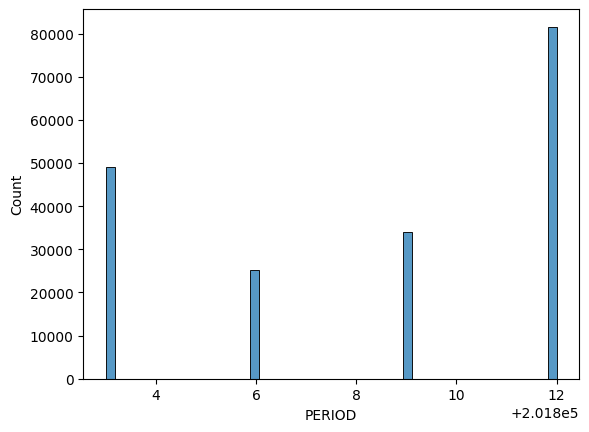

In [129]:
sns.histplot(
    x='PERIOD',
    data=df,
    bins=50,
)
plt.show()

<Axes: xlabel='CITYNAME', ylabel='PRICE'>

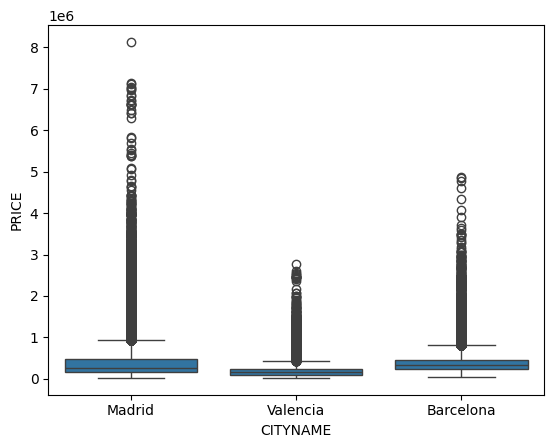

In [121]:
precios=df['PRICE']
k=1.5
media_precio=precios.mean()
q1=np.quantile(precios,q=0.25)
q3=np.quantile(precios,q=0.75)
iqr=q3-q1
lim_i=q1-iqr*k
lim_s=q3+iqr*k
sns.boxplot(
    x='CITYNAME',
    y='PRICE',
    data=df
)

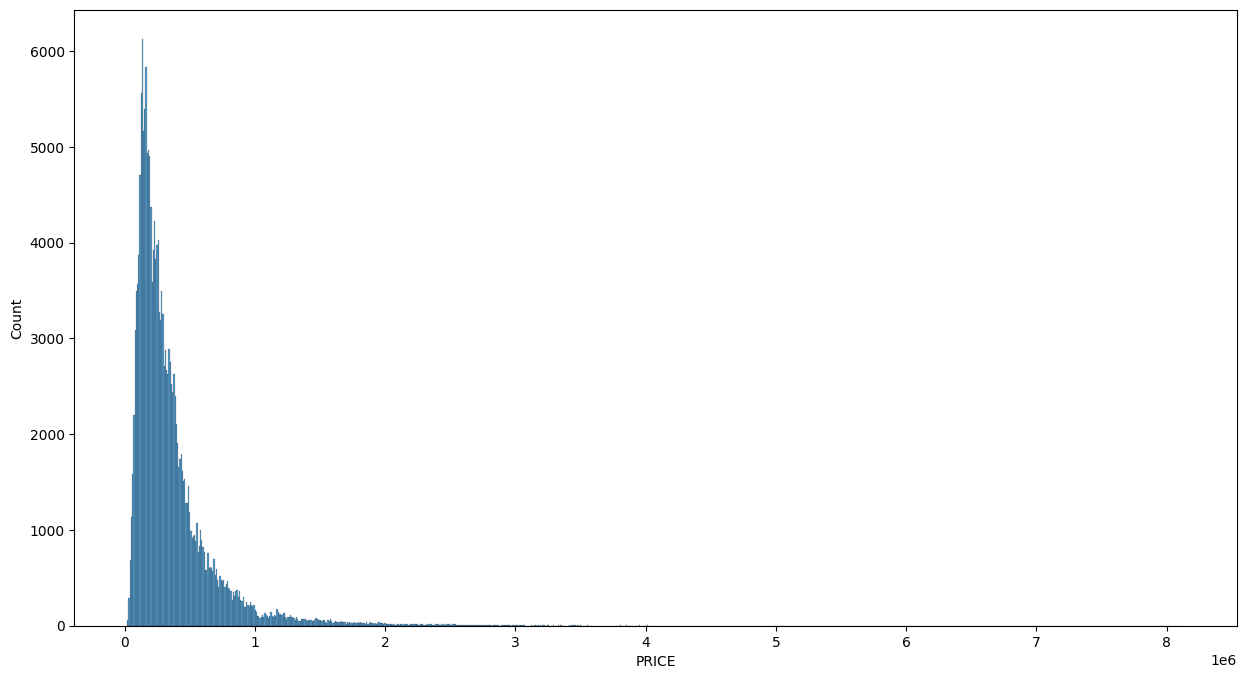

In [ ]:
plt.figure(figsize=(15,8))
sns.histplot(
    x='PRICE',
    data=df
)
plt.show()

<Axes: xlabel='UNITPRICE', ylabel='Count'>

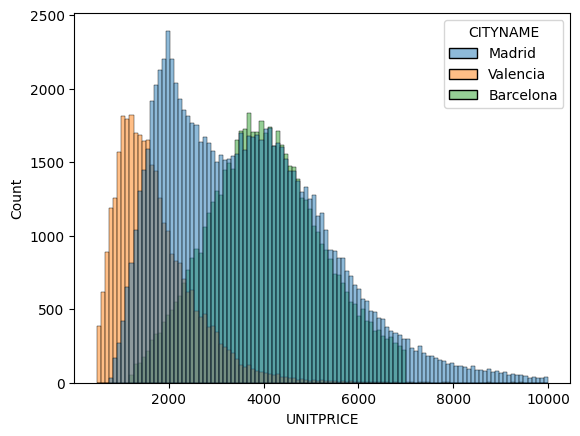

In [74]:
sns.histplot(
    x='UNITPRICE',
    hue='CITYNAME',
    data=df,
)